# Customer Segmentation Analysis using RFM and K-Means Clustering

## Oasis Infobyte Data Analytics Internship - Task 2

### Objective

Segment customers into distinct groups based on purchasing behaviour using RFM Analysis and K-Means Clustering. These segments help businesses create targeted marketing strategies.

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.style.use('ggplot')

pd.set_option('display.max_columns', None)

In [8]:
# Load Dataset

df = pd.read_csv("Dataset/online_retail.csv")

# Display first 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Dataset Inspection

In this section, we inspect the dataset structure, column names, data types, and missing values before performing analysis.

In [10]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Dataset information
print("\nDataset Info:")
df.info()

Shape: (541909, 8)

Columns:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

Data Types:
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [11]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Handling Missing Values

Remove rows with missing CustomerID or Description since they are required for customer analysis.

In [12]:
# Remove missing CustomerID and Description

df = df.dropna(subset=['CustomerID', 'Description'])

# Check again
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

## Removing Invalid Records

Rows with negative quantity or zero price are removed to ensure accurate customer analysis.

In [13]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print(df.shape)

(397884, 8)


In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Calculate Total Purchase Amount

A new column named **TotalAmount** is created by multiplying Quantity and UnitPrice.

In [15]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## RFM Feature Engineering

RFM stands for:

- **Recency:** Days since the customer's last purchase.
- **Frequency:** Number of purchases made by the customer.
- **Monetary:** Total money spent by the customer.

In [16]:
# Latest purchase date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


## Descriptive Statistics

In [17]:
print("Average Purchase Value:", rfm['Monetary'].mean())

print("Average Purchase Frequency:", rfm['Frequency'].mean())

print("Average Customer Lifetime Value:", rfm['Monetary'].mean())

rfm.describe()

Average Purchase Value: 2054.2664601198708
Average Purchase Frequency: 4.272014753342554
Average Customer Lifetime Value: 2054.2664601198708


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


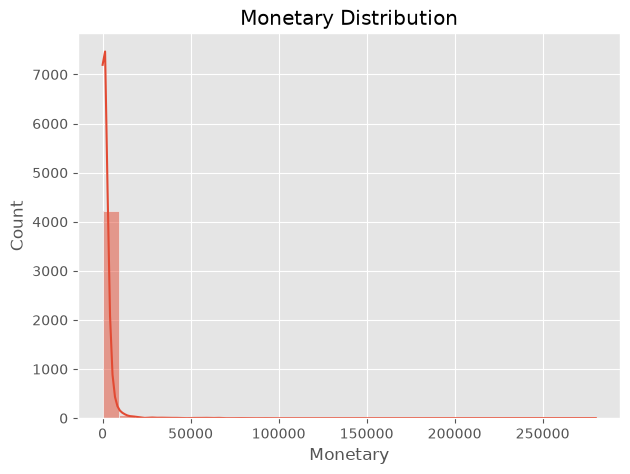

In [18]:
plt.figure(figsize=(7,5))

sns.histplot(rfm['Monetary'], bins=30, kde=True)

plt.title("Monetary Distribution")

plt.savefig("Images/monetary_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

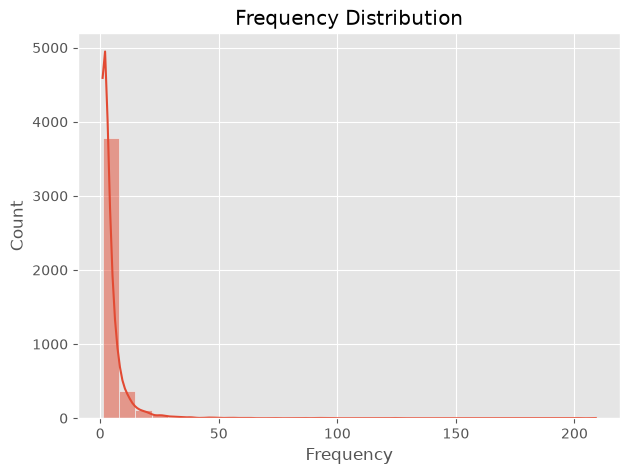

In [19]:
plt.figure(figsize=(7,5))

sns.histplot(rfm['Frequency'], bins=30, kde=True)

plt.title("Frequency Distribution")

plt.savefig("Images/frequency_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

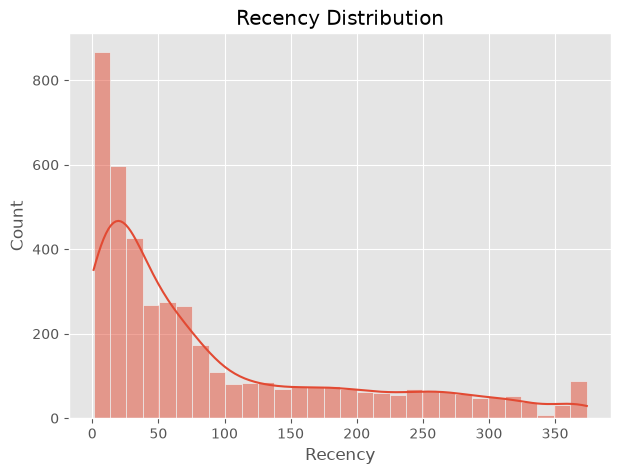

In [20]:
plt.figure(figsize=(7,5))

sns.histplot(rfm['Recency'], bins=30, kde=True)

plt.title("Recency Distribution")

plt.savefig("Images/recency_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Observation

- Customers differ significantly in purchase frequency and total spending.
- Some customers purchase frequently with high monetary value.
- Others purchase rarely and contribute less revenue.
- RFM analysis helps identify valuable customer segments.

## Data Standardization

Before applying K-Means clustering, the RFM features are standardized using StandardScaler.

In [21]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.358668
12347.0,-0.905340,0.354417,0.250966
12348.0,-0.175360,-0.035340,-0.028596
12349.0,-0.735345,-0.425097,-0.033012
12350.0,2.174578,-0.425097,-0.191347


## Elbow Method

The Elbow Method helps determine the optimal number of clusters (K).

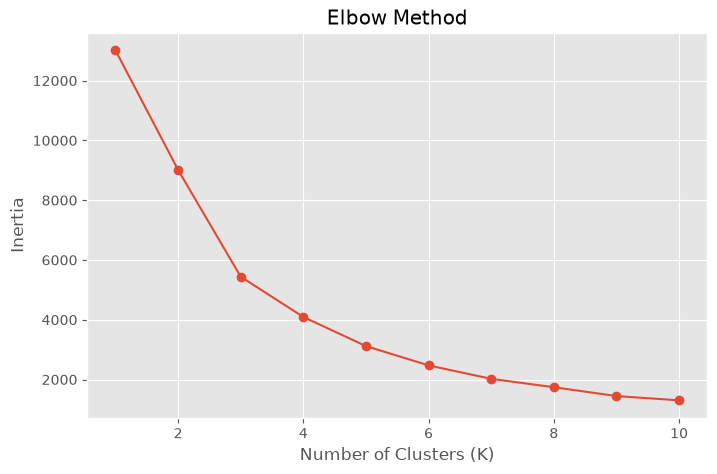

In [22]:
inertia = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.savefig(
    "Images/elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The elbow point indicates the most appropriate number of clusters for customer segmentation.

In [23]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


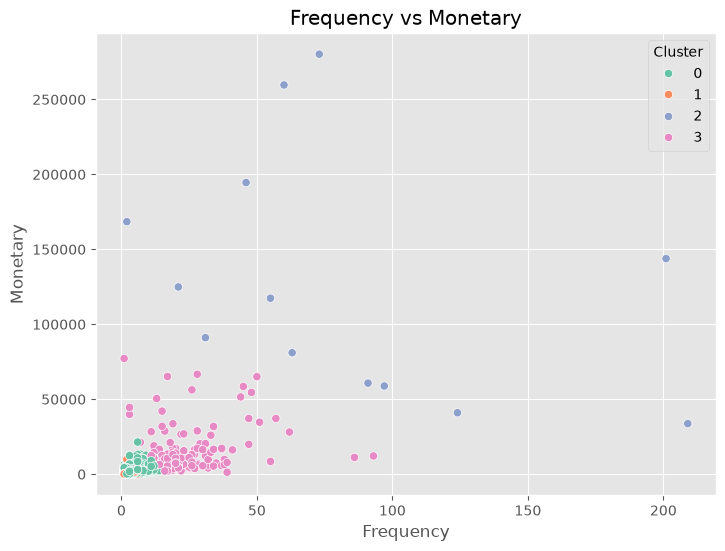

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title("Frequency vs Monetary")

plt.savefig(
    "Images/frequency_vs_monetary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

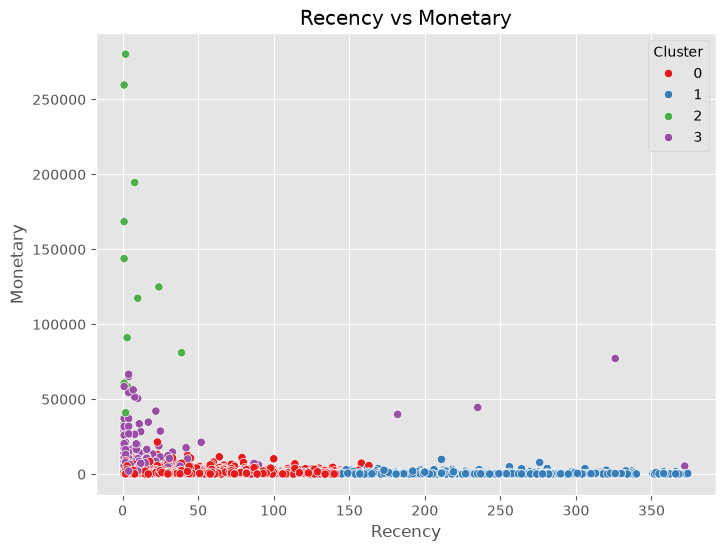

In [25]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set1'
)

plt.title("Recency vs Monetary")

plt.savefig(
    "Images/recency_vs_monetary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
cluster_profile = rfm.groupby('Cluster').mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


## Cluster Interpretation

Each cluster represents customers with similar purchasing behaviour based on Recency, Frequency, and Monetary value.

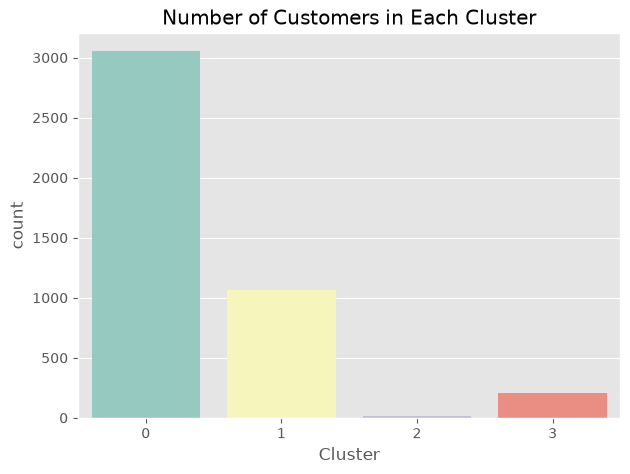

In [28]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Cluster",
    data=rfm,
    hue="Cluster",
    palette="Set3",
    legend=False
)
plt.title("Number of Customers in Each Cluster")

plt.savefig(
    "Images/customers_per_cluster.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Insights and Marketing Recommendations

### Cluster 0
- High-value loyal customers.
- Reward them with exclusive offers and loyalty programs.

### Cluster 1
- Regular customers.
- Encourage repeat purchases through personalized recommendations.

### Cluster 2
- Infrequent customers.
- Offer discounts and promotional campaigns to re-engage them.

### Cluster 3
- New or low-spending customers.
- Introduce welcome offers and product bundles to increase engagement.

## Conclusion

Customer segmentation using RFM Analysis and K-Means clustering enables businesses to create targeted marketing strategies, improve customer retention, and maximize revenue.